# 청크 사이즈 튜닝 실험 — PDF 페이지 데이터

`data/02_processed/pdf/*.jsonl` 을 `ingest_pdf` 의 **전처리(clean)·청킹(chunk) 로직 그대로** 돌려
청크 사이즈/오버랩을 바꿔가며 통계를 비교한다. 실제 임베딩·DB 적재는 하지 않아 가볍다.

1. 문자 수(char) 기준 통계 + ASCII 히스토그램
2. 여러 `(size, overlap)` 후보 비교표
3. 실제 청크 샘플을 눈으로 확인 (경계·오버랩)
4. (선택) **KURE-v1 토크나이저로 토큰 수** 확인 — 임베딩 모델의 진짜 제약
5. (선택) matplotlib 히스토그램

> 커널 작업 디렉터리는 보통 이 노트북이 있는 `backend/test/` 다. 첫 셀이 `backend/` 를 import 경로에 올린다.

## 0. 준비 — 경로 설정 & 로직 import

In [1]:
import sys, statistics
from pathlib import Path

# 이 노트북은 backend/test 에 있다. test/ingest_pdf.py 를 가진 backend/ 를 sys.path 에 올린다.
HERE = Path.cwd()
BACKEND = next((p for p in [HERE, *HERE.parents] if (p / "test" / "ingest_pdf.py").exists()), None)
assert BACKEND is not None, f"backend/ 를 찾지 못했습니다 (cwd={HERE}). backend/test 에서 커널을 실행하세요."
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))
print("backend =", BACKEND)

# 색인 스크립트와 100% 동일한 전처리·청킹 함수를 그대로 쓴다.
from test.ingest_pdf import clean_pdf_text, build_chunks, DEFAULT_DATA_DIR, DEFAULT_MIN_PAGE_CHARS
from test.ingest_kure import iter_records, resolve_data_dir, collect_files
print("import OK — 전처리·청킹 로직 로드됨")

backend = c:\Users\playdata2\workspace\SKN30-4th-4Team-dev\backend
import OK — 전처리·청킹 로직 로드됨


## 1. 데이터 로드 + 전처리

모든 PDF 페이지를 읽어 `clean_pdf_text` 로 정리한 뒤 메모리에 올린다.

In [2]:
DATA_DIR = resolve_data_dir(DEFAULT_DATA_DIR)
files = collect_files(DATA_DIR, "")
print("데이터 폴더:", DATA_DIR)
print("파일:", len(files), "개")

pages = []  # 전처리된 페이지: {content, metadata, file}
for path in files:
    for rec in iter_records(path):
        pages.append({
            "content": clean_pdf_text(rec["content"]),
            "metadata": rec["metadata"],
            "file": path.name,
        })

raw_lens = [len(p["content"]) for p in pages]
print(f"총 페이지: {len(pages)}")
print(f"페이지 길이(문자): min {min(raw_lens)} / median {statistics.median(raw_lens):.0f} "
      f"/ mean {statistics.mean(raw_lens):.0f} / max {max(raw_lens)}")

데이터 폴더: C:\Users\playdata2\workspace\SKN30-4th-4Team-dev\data\02_processed\pdf
파일: 10 개
총 페이지: 716
페이지 길이(문자): min 35 / median 723 / mean 757 / max 2839


## 2. 통계 헬퍼 (문자 수 기준 + ASCII 히스토그램)

In [3]:
def chunk_lengths(size, overlap, min_page_chars=DEFAULT_MIN_PAGE_CHARS):
    """모든 페이지를 주어진 설정으로 청킹해 (청크 길이 리스트, 페이지 통계) 반환."""
    lens, split, single, dropped = [], 0, 0, 0
    for pg in pages:
        chunks = build_chunks(
            {"content": pg["content"], "metadata": pg["metadata"]},
            size, overlap, min_page_chars,
        )
        if not chunks:
            dropped += 1
            continue
        (single := single + 1) if len(chunks) == 1 else (split := split + 1)
        lens.extend(len(c["content"]) for c in chunks)
    return lens, {"pages_split": split, "pages_single": single, "dropped": dropped}


def describe(lens):
    if not lens:
        return {}
    q = statistics.quantiles(lens, n=100) if len(lens) > 1 else [lens[0]] * 99
    return {
        "n": len(lens), "min": min(lens), "p50": int(statistics.median(lens)),
        "mean": round(statistics.mean(lens), 1),
        "p90": round(q[89], 1), "p99": round(q[98], 1), "max": max(lens),
    }


def ascii_hist(lens, bins=12, width=48):
    lo, hi = min(lens), max(lens)
    if hi == lo:
        hi = lo + 1
    step = (hi - lo) / bins
    counts = [0] * bins
    for x in lens:
        counts[min(int((x - lo) / step), bins - 1)] += 1
    top = max(counts) or 1
    for i, c in enumerate(counts):
        a, b = int(lo + i * step), int(lo + (i + 1) * step)
        print(f"{a:>5}-{b:<5} | {chr(9608) * int(c / top * width):<{width}} {c}")

print("헬퍼 준비 완료")

헬퍼 준비 완료


## 3. 단일 설정 테스트

`SIZE` / `OVERLAP` 숫자만 바꿔가며 이 셀을 반복 실행하세요.
오버랩이 앞 청크 꼬리를 다음 청크에 덧붙이므로 **`SIZE` 를 조금 넘는 청크가 나오는 것은 정상**입니다.

In [4]:
SIZE = 1000       # ← 바꿔보세요
OVERLAP = 150     # ← 바꿔보세요

lens, info = chunk_lengths(SIZE, OVERLAP)
print(f"size={SIZE}, overlap={OVERLAP}")
print(f"청크 수: {len(lens)} | 분할된 페이지: {info['pages_split']} "
      f"| 단일 청크 페이지: {info['pages_single']} | 버려진 페이지: {info['dropped']}")
print("길이 통계:", describe(lens))
over = sum(1 for x in lens if x > SIZE)
print(f"size 초과 청크: {over} ({over / len(lens) * 100:.1f}%)  ← 오버랩 때문. 크게 벗어나지 않으면 정상")
print()
ascii_hist(lens)

size=1000, overlap=150
청크 수: 866 | 분할된 페이지: 138 | 단일 청크 페이지: 578 | 버려진 페이지: 0
길이 통계: {'n': 866, 'min': 35, 'p50': 662, 'mean': 651.1, 'p90': 951.3, 'p99': 1091.0, 'max': 1151}
size 초과 청크: 17 (2.0%)  ← 오버랩 때문. 크게 벗어나지 않으면 정상

   35-128   | ███████                                          24
  128-221   | ████                                             15
  221-314   | █████████████████                                54
  314-407   | ████████████████████                             65
  407-500   | ████████████████████████████                     88
  500-593   | ██████████████████████████████                   96
  593-686   | █████████████████████████████████████            116
  686-779   | █████████████████████████████                    92
  779-872   | ████████████████████████████████                 101
  872-965   | ████████████████████████████████████████████████ 149
  965-1058  | █████████████████                                55
 1058-1151  | ███                             

## 4. 여러 후보 비교표

한눈에 비교해서 사이즈를 정합니다. `split`=분할된 페이지 수, `single`=한 청크로 끝난 페이지 수.

In [5]:
CANDIDATES = [(500, 75), (800, 120), (1000, 150), (1200, 180), (1500, 200)]

hdr = f"{'size':>6}{'overlap':>9}{'chunks':>9}{'mean':>8}{'p90':>8}{'p99':>8}{'max':>8}{'split':>8}{'single':>8}"
print(hdr)
print("-" * len(hdr))
for size, overlap in CANDIDATES:
    lens, info = chunk_lengths(size, overlap)
    d = describe(lens)
    print(f"{size:>6}{overlap:>9}{d['n']:>9}{d['mean']:>8}{d['p90']:>8}"
          f"{d['p99']:>8}{d['max']:>8}{info['pages_split']:>8}{info['pages_single']:>8}")

  size  overlap   chunks    mean     p90     p99     max   split  single
------------------------------------------------------------------------
   500       75     1573   384.4   531.0   574.0     576     550     166
   800      120     1045   555.6   782.0   902.5     921     289     427
  1000      150      866   651.1   951.3  1091.0    1151     138     578
  1200      180      789   703.1  1105.0  1199.1    1380      68     648
  1500      200      737   740.8  1191.4  1478.5    1646      21     695


## 5. 실제 청크 샘플 확인

여러 청크로 쪼개진 페이지 하나를 골라 경계와 오버랩이 자연스러운지 눈으로 봅니다.

In [6]:
SAMPLE_SIZE, SAMPLE_OVERLAP = 1000, 150

for pg in pages:
    chunks = build_chunks(
        {"content": pg["content"], "metadata": pg["metadata"]},
        SAMPLE_SIZE, SAMPLE_OVERLAP, DEFAULT_MIN_PAGE_CHARS,
    )
    if len(chunks) >= 3:
        m = pg["metadata"]
        print(f"[{pg['file']}] {m.get('doc_title')} p.{m.get('book_page')} -> {len(chunks)} chunks\n")
        for c in chunks[:3]:
            body = c["content"]
            print(f"-- chunk {c['chunk_index']} (len={len(body)}) --")
            print(body[:220] + (" ..." if len(body) > 220 else ""))
            print("   [끝 60자]:", repr(body[-60:]))
            print()
        break

[counsel_casebook_2024.jsonl] 2024 주택임대차 상담사례집 p.11 -> 4 chunks

-- chunk 0 (len=43) --
제1장. 제도소개

###### ➌ 조정절차 일반사항

###### 조정절차도
   [끝 60자]: '제1장. 제도소개\n\n###### ➌ 조정절차 일반사항\n\n###### 조정절차도'

-- chunk 1 (len=1015) --
제1장. 제도소개

###### ➌ 조정절차 일반사항

###### 조정절차도 주택·상가건물 임대차분쟁조정위원회 분쟁 조정 제도 상세 절차
온라인 홈페이지, 방문, 우편, 팩스 등
조정신청 임차인, 임대인 누구나 신청가능!
수수료: 1만원-최대 10만원 (면제사유 해당 시 무료)
분쟁조정 신청 대상 : 차임 또는 보증금에 관한 분쟁, 임대차 기간에 관한 분쟁,
보증금 또는 임차주택·상가건물에 ...
   [끝 60자]: '부터 14일 이내에 수락의 의사를\n서면으로 표시하지 아니한 경우 조정이 불성립한 것으로 봄\n(조정절차 종료)'

-- chunk 2 (len=261) --
의록 작성
조정절차 중 합의 X
조정안 제시 조정위원회의 의결에 따른
조정안 제시 및 조정서 작성
조정안 작성 및 송달 조정불성립
당사자가 조정안을 통지받은 날로부터 14일 이내에 수락의 의사를
서면으로 표시하지 아니한 경우 조정이 불성립한 것으로 봄
(조정절차 종료) ・양당사자 모두 14일 이내에 수락의 의사를 서면으로 표시한 때 합의에 의한 조정 성립으로 간주
조정성립 ・강제집행을 승낙하 ...
   [끝 60자]: ' 간주\n조정성립 ・강제집행을 승낙하는 취지의 내용이 기재된 조정서의 정본은 집행력있는 집행 권원과 같은 효력'



## 6. (선택) KURE-v1 토크나이저로 토큰 수 확인

임베딩 모델은 문자가 아니라 **토큰**으로 자른다. `SIZE`(문자)가 모델 max token 을 넘으면
뒤가 잘려 임베딩 품질이 떨어진다. 이 셀은 (모델 전체가 아니라) **토크나이저만** 내려받는다.
`transformers` 가 없으면 조용히 건너뛴다.

In [7]:
try:
    from transformers import AutoTokenizer
    import random

    tok = AutoTokenizer.from_pretrained("nlpai-lab/KURE-v1")
    max_len = tok.model_max_length
    max_txt = max_len if max_len < 100000 else "unknown(대형 sentinel)"
    print("model_max_length =", max_txt)

    SIZE, OVERLAP = 1000, 150
    texts = []
    for pg in pages:
        chunks = build_chunks(
            {"content": pg["content"], "metadata": pg["metadata"]},
            SIZE, OVERLAP, DEFAULT_MIN_PAGE_CHARS,
        )
        texts.extend(c["content"] for c in chunks)

    random.seed(0)
    sub = texts if len(texts) <= 800 else random.sample(texts, 800)
    tok_lens = [len(tok.encode(t, add_special_tokens=True)) for t in sub]
    print(f"토큰 수(표본 {len(sub)}): {describe(tok_lens)}")

    if isinstance(max_len, int) and max_len < 100000:
        over = sum(1 for x in tok_lens if x > max_len)
        print(f"max_length 초과 청크: {over} ({over / len(tok_lens) * 100:.1f}%)")
        print("→ 초과가 있으면 SIZE(문자)를 줄이세요. 한국어는 대략 1토큰 ≈ 1~2글자.")
    print()
    ascii_hist(tok_lens)
except Exception as e:
    print("토크나이저 확인 건너뜀:", type(e).__name__, e)
    print("필요하면: pip install transformers")

c:\Users\playdata2\workspace\SKN30-4th-4Team-dev\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model_max_length = 8192
토큰 수(표본 800): {'n': 800, 'min': 24, 'p50': 377, 'mean': 373.8, 'p90': 545.0, 'p99': 678.0, 'max': 901}
max_length 초과 청크: 0 (0.0%)
→ 초과가 있으면 SIZE(문자)를 줄이세요. 한국어는 대략 1토큰 ≈ 1~2글자.

   24-97    | ████████                                         27
   97-170   | █████████████                                    45
  170-243   | █████████████████████████████                    98
  243-316   | ████████████████████████████                     95
  316-389   | ███████████████████████████████████████████████  157
  389-462   | ███████████████████████████████████              117
  462-535   | ████████████████████████████████████████████████ 159
  535-608   | ███████████████████████                          79
  608-681   | ████                                             16
  681-754   |                                                  3
  754-827   |                                                  2
  827-901   |                                                  2


## 7. (선택) matplotlib 히스토그램

`matplotlib` 이 설치돼 있으면 그림으로 본다. 없으면 건너뛴다.

C:\Users\playdata2\AppData\Local\Temp\ipykernel_3820\3253899316.py:13: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_3820\3253899316.py:13: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_3820\3253899316.py:13: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_3820\3253899316.py:13: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_3820\3253899316.py:13: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_3820\3253899316.py:13: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE

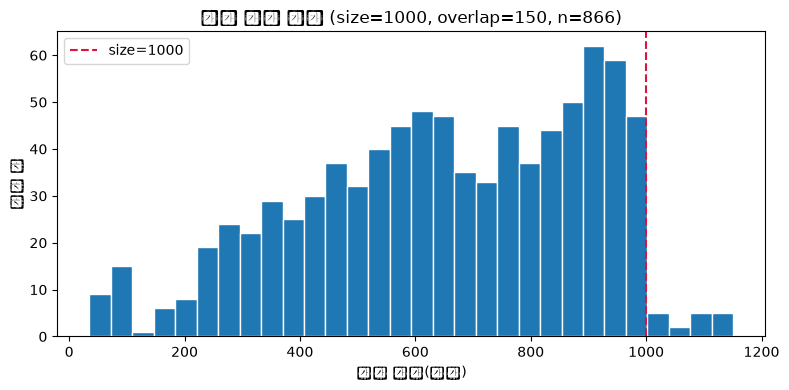

In [9]:
try:
    import matplotlib.pyplot as plt

    SIZE, OVERLAP = 1000, 150
    lens, _ = chunk_lengths(SIZE, OVERLAP)
    plt.figure(figsize=(8, 4))
    plt.hist(lens, bins=30, edgecolor="white")
    plt.axvline(SIZE, color="crimson", linestyle="--", label=f"size={SIZE}")
    plt.title(f"청크 길이 분포 (size={SIZE}, overlap={OVERLAP}, n={len(lens)})")
    plt.xlabel("청크 길이(문자)")
    plt.ylabel("청크 수")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib 미설치 — 건너뜀 (pip install matplotlib). 3번 셀의 ASCII 히스토그램을 쓰세요.")